# Prepare the structures and the features for R, P, M and $\delta$ phases

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
from Tools.DatasetTools.DatasetOperator import Dataset
from Tools.PredictionTools.MakeAtomsOjects import make_all_atoms_objects, permutate, old_permutate
import joblib
from dependencies.bopdftprojections.bopdftprojections.projections import Projections
from Tools import PlottingTools as plotting
from Tools.DatasetTools.GeneralFeaturizer import cn_persite
from importlib.machinery import SourceFileLoader
import logging
dataset = 'Fe-Mo' #'Cr-Co-W'
NameForFile = 'FeMo'
MAG = 1
if MAG == 0:
    target_case = 'EF_nmhcp'
elif MAG == 1:
    target_case = 'EF_fmbcc'

descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')

/home/mariano/.local/micromamba/envs/datasets_ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logger = logging.getLogger()
logging.basicConfig( format='%(message)s',level=logging.INFO,)


In [3]:
import shutil

# Enable LaTeX text rendering only if a TeX Live toolchain is available.
required_tex_bins = ("latex", "dvipng", "kpsewhich")
has_texlive = all(shutil.which(cmd) is not None for cmd in required_tex_bins)

plt.rc("text", usetex=has_texlive)
plt.rc("font", family="serif", size=24)
plt.rc("xtick", labelsize=18)
plt.rc("ytick", labelsize=18)
plt.rc("axes", labelsize=18)

if not has_texlive:
    print(
        "TeX Live not fully available (missing one of: latex, dvipng, kpsewhich). "
        "Using matplotlib internal text rendering."
    )

In [4]:
import logging

In [5]:
from mendeleev import element


In [6]:
DS = Dataset(dataset=dataset, remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"')
BS = DS.BS #pd.read_pickle(f'{dataset}/FullyCuratedParsedBriefSummary.pkl')
BS = BS.loc[~BS.index.str.contains('delta')]
TRAIN_RBS = BS.query('Phase == "R"')

In [7]:
BS.filter(regex = "EF")

,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,0.374554,0.363607,0.351444
...,...,...,...
Fe_pv30.sigma.FM,0.075258,0.075258,0.075258
Fe_pv6.C15.FM,0.144169,0.144169,0.144169
Mo_sv8.A15.NM,0.095306,0.095306,0.095306
Mo_sv6.C15.NM,0.367463,0.367463,0.367463


In [8]:
target_case

'EF_fmbcc'

In [9]:
DS.StructureNames[DS.StructureNames == 'M']

Series([], Name: Phase, dtype: object)

In [10]:
train_features = DS.Features

In [11]:
train_features['atomic']['Structure'].max()

10

In [12]:
train_features['atomic']['Structure'].min()

0

In [13]:
pd.concat([ DS.StructureNames, train_features['atomic']['Structure']], axis =1 ).reset_index(drop=True).drop_duplicates().sort_values('Structure')

,Phase,Structure
179,A15,0
6,C14,1
178,C15,2
0,C36,3
1,R,4
11,chi,6
2,mu,9
3,sigma,10


Text(0, 0.5, '$\\Delta E_F$ (meV/at)')

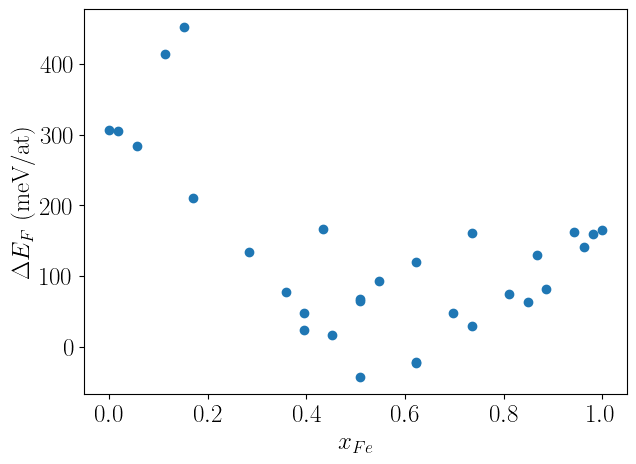

In [14]:
fig, axes = plt.subplots()
axes.scatter(TRAIN_RBS['Fe_pv'], TRAIN_RBS['EF_nmhcp']*1000)
axes.set_xlabel('$x_{Fe}$')
axes.set_ylabel(r'$\Delta E_F$ (meV/at)')

In [15]:
CNListLocation = os.path.join(descriptorlocation,'CNList.pkl')
CNList = pd.read_pickle(CNListLocation)

In [16]:
LearningAtomsObjects = pd.read_pickle('Fe-Mo/Atomsobjects/Fe-Mo-POSCAR-initial-rescaled-AtomsObjects.pkl').query('index.str.contains("R-.*NM$")')

In [17]:
binaries_predict = {'R' :
#                        {'permutations': LearningAtomsObjects.index.str.split('\.').map(lambda s: s[1]),
#                         'atoms_objects_file': os.path.join(dataset,'Atomsobjects/R_structures.pkl')}
                    {'permutations': permutate('R', 2, 11), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/R_structures.pkl')}, 
#                    'R_old':
#                    {'permutations': old_permutate('R', 2, 11), 'atoms_objects_file': os.path.join(dataset, 'Atomsobjects/R_structures_old.pkl')},
                    'P' : 
                    {'permutations': permutate('P', 2, 12), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/P_structures.pkl')},
#                    'P_old' : 
#                    {'permutations': old_permutate('P', 2, 12), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects/P_structures.pkl')},
                    'delta': 
                    {'permutations': permutate('delta', 2, 14), 'atoms_objects_file' : os.path.join(dataset,'Atomsobjects/delta_structures.pkl') },
                    'M':
                    {'permutations': permutate('M', 2, 11 ), 'atoms_objects_file': os.path.join(dataset,'Atomsobjects', 'M_structures.pkl' )}
                   }

In [18]:
binaries_predict['R']['permutations'][0], binaries_predict['R']['permutations'][-1], 

('R-AAAAAAAAAAA', 'R-BBBBBBBBBBB')

In [19]:
import Tools.PredictionTools.MakeAtomsOjects as MAO

In [20]:

atom_volumes = {'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [21]:
#atom_volumes = MAO.get_atom_volume_from_mp({'Fe' : 'mp-13', 'Mo' : 'mp-129'})
# was taking volumes from MP , but MPRester is not working due to incompatibilities

In [22]:
atom_volumes

{'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [23]:
for name, binary in binaries_predict.items():
    print(name)
    if os.path.exists(binary['atoms_objects_file']):
        binary['Atoms'] = pd.read_pickle(binary['atoms_objects_file'])
    else:
        binary['Atoms'] = make_all_atoms_objects(binary['permutations'], atom_volumes_def=atom_volumes)
        binary['Atoms'] = binary['Atoms'].to_frame()
        binary['Atoms'].index = binary['Atoms'].index +'.NM'
        binary['Atoms'].columns = ['atoms']
        binary['Atoms'].to_pickle(binary['atoms_objects_file'])
binaries_predict['R']['Atoms'].index = binaries_predict['R']['Atoms'].index.str.replace("-AAAAAAAAAAA", '')
binaries_predict['R']['Atoms'].index = binaries_predict['R']['Atoms'].index.str.replace("-BBBBBBBBBBB", '')

R
P
delta
M


In [24]:
binaries_predict['R']['Atoms']

,atoms
Fe_pv53.R.NM,"(Atom('Fe', [5.614366370550564, 5.130930694031..."
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,"(Atom('Fe', [5.688450365423163, 5.198635545859..."
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,"(Atom('Fe', [5.63927762944244, 5.1536969216767..."
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,"(Atom('Fe', [5.712721111029581, 5.220816412832..."
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,"(Atom('Fe', [5.688450365423163, 5.198635545859..."
...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,"(Atom('Mo', [6.149712932802712, 5.620180224060..."
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,"(Atom('Mo', [6.12878666841063, 5.6010558553976..."
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,"(Atom('Mo', [6.191143463482836, 5.658043300231..."
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,"(Atom('Mo', [6.149712932802712, 5.620180224060..."


In [25]:
len(binaries_predict['R']['Atoms'].iloc[0].values[0])

53

In [26]:
len(binaries_predict['M']['Atoms'].iloc[0].values[0])

52

In [27]:
len(binaries_predict['P']['Atoms'].iloc[0].values[0])

56

In [28]:
len(binaries_predict['delta']['Atoms'].iloc[0].values[0])

56

## compare atoms objects to the ones used for learning

Text(0.5, 0, 'volume of unit cell in training set')

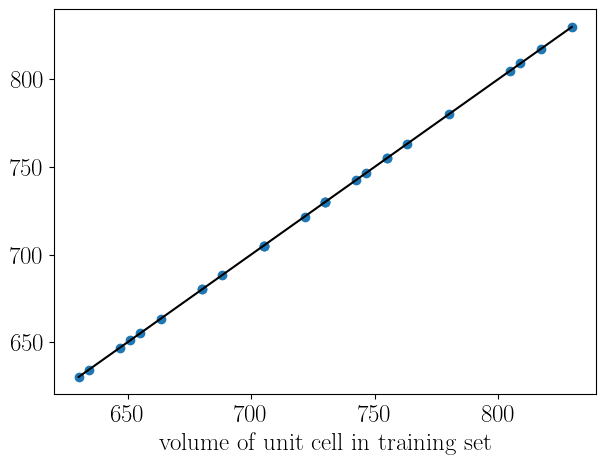

In [29]:
not_created = binaries_predict['R']['Atoms'].index.difference(LearningAtomsObjects.index)

intersection = LearningAtomsObjects.index.intersection(binaries_predict['R']['Atoms'].index)

created_intersection_volumes = binaries_predict['R']['Atoms'].atoms[intersection].map(lambda a: a.get_volume())

#alt_created_intersection_volumes = binaries_predict['R_old']['Atoms'].atoms[intersection].map(lambda a: a.get_volume())


intersection_volumes = LearningAtomsObjects.atoms[intersection].map(lambda a: a.get_volume())

fig, axes = plt.subplots()
axes.scatter(intersection_volumes, created_intersection_volumes)
#axes.scatter(intersection_volumes, alt_created_intersection_volumes)
axes.plot([ created_intersection_volumes.min(), created_intersection_volumes.max() ], [ created_intersection_volumes.min(), created_intersection_volumes.max() ], '-k')
axes.set_xlabel('volume of created unit cell')
axes.set_xlabel('volume of unit cell in training set')

In [30]:
theatoms=binaries_predict['P']['Atoms'].atoms.sample(n=1).iloc[0]
plotting.plotly_atoms(theatoms)

In [31]:
theatoms=binaries_predict['R']['Atoms'].atoms.sample(n=1).iloc[0]
plotting.plotly_atoms(theatoms)

In [32]:
theatoms=binaries_predict['delta']['Atoms'].atoms.sample(n=1).iloc[0]
plotting.plotly_atoms(theatoms)

In [33]:
theatoms=binaries_predict['M']['Atoms'].atoms.sample(n=1).iloc[0]
plotting.plotly_atoms(theatoms)

# Make BS 

In [34]:
def get_nelem(a):
    return len(np.unique(a.get_chemical_symbols()))

In [35]:
BS_predict = {}
for name, binarypredict in binaries_predict.items():
    BS_predict[name] = binarypredict['Atoms'].atoms.map(len)
    BS_predict[name].name = 'num_atoms'
    compo = pd.DataFrame.from_dict(
        binarypredict['Atoms'].atoms.map(lambda a: pd.Series(a.symbols).value_counts().to_dict()).to_dict(),
        orient = 'index'
    ).fillna(0)
    compo['Fe_pv'] = compo['Fe'] / BS_predict[name]
    compo['Mo_sv'] = 1 - compo['Fe_pv']
    compo['Mag'] = MAG #FM
    compo['nelem'] = binarypredict['Atoms'].atoms.map(get_nelem)
    BS_predict[name] = pd.concat([BS_predict[name], compo], axis = 1)

In [36]:
BS_predict['P']

,num_atoms,Fe,Mo,Fe_pv,Mo_sv,Mag,nelem
Fe_pv56.P-AAAAAAAAAAAA.NM,56,56.0,0.0,1.000000,0.000000,1,1
Fe_pv48Mo_sv8.P-AAAAAAAAAAAB.NM,56,48.0,8.0,0.857143,0.142857,1,2
Fe_pv48Mo_sv8.P-AAAAAAAAAABA.NM,56,48.0,8.0,0.857143,0.142857,1,2
Fe_pv40Mo_sv16.P-AAAAAAAAAABB.NM,56,40.0,16.0,0.714286,0.285714,1,2
Fe_pv52Mo_sv4.P-AAAAAAAAABAA.NM,56,52.0,4.0,0.928571,0.071429,1,2
...,...,...,...,...,...,...,...
Fe_pv4Mo_sv52.P-BBBBBBBBBABB.NM,56,4.0,52.0,0.071429,0.928571,1,2
Fe_pv16Mo_sv40.P-BBBBBBBBBBAA.NM,56,16.0,40.0,0.285714,0.714286,1,2
Fe_pv8Mo_sv48.P-BBBBBBBBBBAB.NM,56,8.0,48.0,0.142857,0.857143,1,2
Fe_pv8Mo_sv48.P-BBBBBBBBBBBA.NM,56,8.0,48.0,0.142857,0.857143,1,2


In [37]:
BS_predict['R']['Structure'] = 4
#BS_predict['R_old']['Structure'] = 4

In [38]:
BS_predict['P']['Structure'] = 11

In [39]:
BS_predict['delta']['Structure'] = 11

In [40]:
BS_predict['M']['Structure'] = 11

In [41]:
BS.query('Phase == "R"').columns

Index(['', 'V', 'E0', 'B', 'fit', 'xc', 'encut', 'deltak', 'ncrash', 'nelem',
       'B0', 'V0', 'atom_A', 'atom_B', 'num_atom_A', 'num_atom_B', 'num_atoms',
       'Fe_pv', 'Mo_sv', 'Mag', 'Phase', 'EF_fmbcc', 'EF_nmhcp', 'EF_nmfcc'],
      dtype='object')

# CALCULATE FEATURES AND APPLY CN AVERAGE. THE ATOMS OBJECTS ARE ALREADY ORDERED !

# Load BOP Features 

In [42]:
globalmoments = 16
model_definitions = {
    '0.7dprojections_0.5os': {'model_maker_options' : {
        'element_pairs_kwargs' : {
            'bond_integral_scale': 0.7,
        },
        'atom_blocks_kwargs': {
            'onsite_levels_scale' : 0.5,
            'select_orbitals' : {'Fe': 'd', 'Mo' : 'd'}
        },
    },
    'moments' : globalmoments
    },
}
cutoff = 'table'
atoms = ['initial', 'relaxed']
retry = False

In [43]:
P = Projections()
P.readbxmodels()
P.get_bond_chunks()
P.get_autobonds()
P.get_all_onsite_levels()
P.get_restructured_projections()

using merged projections


filling inverted bonds: 100%|██████████| 3868/3868 [00:00<00:00, 1754088.86it/s]


In [44]:
def create_modelfile(acompound, target_model_filename, modelname='projections', element_pairs_kwargs={}, atom_blocks_kwargs={} ):
    print(acompound)
    if 'canonical' not in modelname :
        model_filename = P.save_abond_bx(acompound, return_filename=True,
                                         modelname=modelname, 
                                         element_pairs_kwargs=element_pairs_kwargs,
                                         atom_blocks_kwargs=atom_blocks_kwargs)
        print(model_filename)
    else:
        model_filename = C.base_canonical #f'models/W_canonical.bx'
    shutil.copy(model_filename, target_model_filename)

In [45]:
def replace_symbols(theatoms, replacements=None):
    new_symbols = theatoms.get_chemical_symbols()
    if replacements is not None:
        for original, replacement in replacements.items():
            new_symbols = [s.replace(original, replacement) for s in new_symbols]
    new_atoms = theatoms.copy()
    new_atoms.set_chemical_symbols(new_symbols)
    return new_atoms


In [46]:
AtomsObjects = {}
for name, binary in binaries_predict.items():
    AtomsObjects[name]  = binary['Atoms']

In [47]:
results = {}
resultspickle = {}

In [48]:
elements = dataset.split('-')

In [49]:
import shutil

In [50]:
from BopFoxFeaturizer.Featurizer import BopfoxFeatures
print("bopfoxfeaturizer import OK")

bopfoxfeaturizer import OK


In [51]:
from Tools.DatasetTools.Commoms import *
os.environ['PATH']+=':'+os.path.join(os.getcwd(),'dependencies/bopfox/src/')
from BopFoxFeaturizer.Featurizer import Featurizer, BopfoxFeatures

In [52]:
for (model, definition), (case, atoms_df) in product(model_definitions.items(), AtomsObjects.items()):
    if 'moments' in definition.keys():
        thismoments = definition['moments']
    else:
        thismoments = 16
    if (model, thismoments, case) in results.keys():
        continue
    create_model_options = {}
    if 'model_maker_options' in definition.keys():
        create_model_options.update(definition['model_maker_options'])
    use_elements = copy.copy(elements)
    if 'replace atoms' in definition.keys():
        for realelement, targetelement in definition['replace atoms'].items():
            use_elements = set([s.replace(realelement, targetelement) for s in use_elements])
    components = ''.join(use_elements)
    modelsfile = os.path.join('models', f'{dataset}-{components}_{model}.bx')
    if not os.path.exists(os.path.dirname(modelsfile)):
        os.makedirs(os.path.dirname(modelsfile))
    create_modelfile(use_elements,modelsfile, modelname=model, **create_model_options,   )
    if 'replace atoms' in definition.keys():
        ApplyOnAtoms = atoms_df['atoms'].apply(replace_symbols, replacements = definition['replace atoms'])
    else:
        ApplyOnAtoms = atoms_df.atoms
    print('atoms: ', case, 'model: ', model, '  cutoff: ', cutoff, ' moments:', thismoments)
    resultspickle[(model, thismoments, case)] = os.path.join(dataset, 'Descriptors', f'PREDICTION_{dataset}_{case}_{model}_{cutoff}_WUBIND_{thismoments}.pkl')
    if not os.path.exists(resultspickle[(model, thismoments, case)]):
        cwd = os.getcwd()
        BOPC = BopfoxFeatures(
            ApplyOnAtoms,modelsfile, modelname=model,
            cutoffby=cutoff, 
            binary = os.path.join(cwd, 'dependencies', 'bopfox','src', 'bopfox'),
            moments = thismoments,
            savelog=False
            )
        BOPC.featurize_dataframe(input_pickle=resultspickle, output_pickle=resultspickle, max_workers=12)
        results[(model, thismoments, case)] = BOPC.RESULTS #pd.read_pickle(resultspickle[model]) 
        results[(model, thismoments, case)].to_pickle(resultspickle[(model, thismoments, case)])
    else:
        results[(model, thismoments, case)] = pd.read_pickle(resultspickle[(model, thismoments, case)])

['Fe', 'Mo']
Fe_Mo.bx
atoms:  R model:  0.7dprojections_0.5os   cutoff:  table  moments: 16
['Fe', 'Mo']
Fe_Mo.bx
atoms:  P model:  0.7dprojections_0.5os   cutoff:  table  moments: 16
['Fe', 'Mo']
Fe_Mo.bx
atoms:  delta model:  0.7dprojections_0.5os   cutoff:  table  moments: 16
['Fe', 'Mo']
Fe_Mo.bx
atoms:  M model:  0.7dprojections_0.5os   cutoff:  table  moments: 16


In [53]:
modelsfile

'models/Fe-Mo-FeMo_0.7dprojections_0.5os.bx'

In [54]:
for (model, thismoments, case), result in results.items(): 
    if not result.index.str.contains('NM$', regex=True).all():
        result.index = result.index+'.NM'
        results[(model, thismoments, case)].to_pickle(resultspickle[(model, thismoments, case)])

In [55]:
cn_persite['R_old'] = cn_persite['R']
cn_persite['P_old'] = cn_persite['P']

In [56]:
cn_persite

{'A15': array([14, 14, 14, 14, 14, 14, 12, 12]),
 'C14': array([16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 12]),
 'C15': array([16, 16, 12, 12, 12, 12]),
 'C36': array([16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 12, 12, 12, 12, 12, 12,
        12, 12, 12, 12, 12, 12, 12]),
 'bcc': array([14]),
 'chi': array([16, 16, 16, 16, 16, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12]),
 'fcc': array([12]),
 'hcp': array([12, 12]),
 'mu': array([12, 12, 12, 12, 12, 12, 12, 15, 15, 16, 16, 14, 14]),
 'sigma': array([12, 12, 15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 12, 12, 12,
        12, 12, 12, 12, 12, 14, 14, 14, 14, 14, 14, 14, 14]),
 'R': array([12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 14, 14, 14, 14, 14, 14, 14,
        14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16,
        16, 16]),
 'delta': array([15, 15, 15, 15, 15, 15, 15, 15, 1

In [57]:
for name, struc in cn_persite.items():
    print(name, len(struc))

A15 8
C14 12
C15 6
C36 24
bcc 1
chi 29
fcc 1
hcp 2
mu 13
sigma 30
R 53
delta 56
P 56
M 52
R_old 53
P_old 56


In [58]:
for phase, list_of_atoms in AtomsObjects.items():
    print(phase, len(list_of_atoms))

R 2048
P 4096
delta 16384
M 2048


In [59]:
featurescnav = {}
for name, result  in results.items():
    specialcolumns =['U_bind','U_bond_atom', 'modelsfile']#, 'U_bond_atom_list'] 
    averaged_bop_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(resultspickle[name]))

    CNList = pd.Series([cn_persite[name[-1]]]*len(result), index=result.index)

    if os.path.exists(averaged_bop_file):
        featurescnav[name] = pd.read_pickle(averaged_bop_file).astype(float)  # for some reason some values are objects
    else:
        columnstoexpand = result.columns.drop([column for column in specialcolumns if column in result.columns])
        df = gf.array_expansions(result.dropna(), columnstoexpand)
        ThisCoordination = CNList[result.index]
        print(name)
        df = gf.featurize_dataframe(df, ThisCoordination)
        shape_factors = gf.get_shape_factors(df)
        featurescnav[name] = pd.concat(
            [
                BS_predict[name[-1]][['Mag', 'Structure']].loc[df.index], 
                result[specialcolumns[:-1]].loc[df.index],
                df, shape_factors
            ],
                axis=1)
        featurescnav[name].to_pickle(averaged_bop_file)

# Load ACE features

In [60]:
from Tools.DatasetTools.ACEDescriptors import MyPyACECalculator 
from Tools.DatasetTools.ACEDescriptors import default_options_dict as default_options_dict
from pyace import ACEBBasisSet, PyACECalculator

In [61]:
AceConfig = copy.copy(default_options_dict)

In [62]:
AceConfig['elements'] = dataset.split('-')

In [63]:
resultsace = {}

In [64]:
model = 'ACE'
description = 'lmax=321'

ACEer = MyPyACECalculator(components=components, multispace_basis_config=AceConfig)
acer = MyPyACECalculator(components, multispace_basis_config=AceConfig)

for case, atoms_df in AtomsObjects.items():
    ApplyOnAtoms = atoms_df.atoms
    print('atoms: ', case, 'model: ', 'ACE')
    resultspickle[(model, description, case)] = os.path.join(dataset, 'Descriptors', f'PREDICTION_{dataset}_{case}_{model}_{description}.pkl')
    print('atoms: ', case, 'model: ', 'ACE', resultspickle[(model, description, case)])
    if not os.path.exists(resultspickle[(model, description, case)]):
        cwd = os.getcwd()
        results[(model, description, case)] = acer.featurize_series(atoms_df.atoms)
        results[(model, description, case)].name = 'ace_projections'
        results[(model, description, case)] = results[(model, description, case)].to_frame()
        results[(model, description, case)].to_pickle(resultspickle[(model, description, case)])
    else:
        results[(model, description, case)] = pd.read_pickle(resultspickle[(model, description, case)])
        if isinstance(results[(model, description, case)], pd.core.series.Series):
            results[(model, description, case)] = results[(model, description, case)].to_frame()
            results[(model, description, case)].columns = ['ace_projections']

atoms:  R model:  ACE
atoms:  R model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_R_ACE_lmax=321.pkl
atoms:  P model:  ACE
atoms:  P model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_P_ACE_lmax=321.pkl
atoms:  delta model:  ACE
atoms:  delta model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_delta_ACE_lmax=321.pkl
atoms:  M model:  ACE
atoms:  M model:  ACE Fe-Mo/Descriptors/PREDICTION_Fe-Mo_M_ACE_lmax=321.pkl


In [65]:
for (model, descriptor, case), features in results.items():
#    if 'ACE' not in model:
#        continue
    print(model, descriptor, case)
    averaged_ace_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(resultspickle[(model, descriptor, case)]))
    columnstoexpand = features.columns
    CNList = pd.Series([cn_persite[case]]*len(features), index=features.index)
    if os.path.exists(averaged_ace_file):
        featurescnav[(model, descriptor, case)] = pd.read_pickle(averaged_ace_file)
    else:
        expanded_ace = gf.array_expansions(features, ['ace_projections'])
        featurescnav[(model, descriptor, case)] = gf.featurize_dataframe(expanded_ace, CNList)
        featurescnav[(model, descriptor, case)].to_pickle(averaged_ace_file)

0.7dprojections_0.5os 16 R
0.7dprojections_0.5os 16 P
0.7dprojections_0.5os 16 delta
0.7dprojections_0.5os 16 M
ACE lmax=321 R
ACE lmax=321 P
ACE lmax=321 delta
ACE lmax=321 M


# load SOAP

In [66]:
soapcases = ['specific']

In [67]:
from dscribe.descriptors import SOAP
from mendeleev import element
import ase
from sklearn.feature_selection import VarianceThreshold

In [68]:
SOAPFEATURES = {}
EXPANDED_SOAP = {}
AVE_SOAP = {}
variances = {}
SEL_SOAP = {}
FINAL_SOAP = {}
soap_params = dict(
    r_cut = 4,
    n_max = 5,
    l_max = 4, # f
    sigma = 0.1,
    rbf = 'gto',
    periodic = True,
)
params_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])
soap_features_file={}

In [69]:
EXPANDED_SOAP.keys()

dict_keys([])

In [70]:
for index, atom in atoms_df['atoms'].items():
    atom.calc = None

In [71]:
for case, atoms_df in  AtomsObjects.items():
    for soapcase in soapcases:
        if (case, soapcase) in AVE_SOAP:
          continue
        logger.info('case: %s, soap case: %s '%(case, soapcase))
        soap_features_file.update({(case,soapcase): os.path.join(dataset,'Descriptors', f'PREDICTION__prediction__{case}__{soapcase}__{params_str}.csv')})
        if os.path.exists(soap_features_file[(case, soapcase)]):
          AVE_SOAP[(case, soapcase)] = pd.read_csv(soap_features_file[(case, soapcase)], index_col = 0)
          continue
        species = [element(s).atomic_number for s in dataset.split('-')]
        thisatomsobjects = atoms_df['atoms'].map(lambda a: copy.copy(a))
        SOAPER = SOAP(species=species, **soap_params)
        SOAPFEATURES.update({( case, soapcase ): thisatomsobjects.map(SOAPER.create)}) #,pd.DataFrame(data= columns=['SOAP'])
        EXPANDED_SOAP.update({( case,soapcase ): gf.array_expansions(SOAPFEATURES[( case, soapcase )].to_frame(name='SOAP'), ['SOAP'])})
        CNList = pd.Series([cn_persite[case]]*len(EXPANDED_SOAP[(case,soapcase)]), index=EXPANDED_SOAP[( case,soapcase )].index)
        AVE_SOAP.update({(case, soapcase): gf.featurize_dataframe(EXPANDED_SOAP[( case, soapcase )], CNList)})
        AVE_SOAP[( case, soapcase )].to_csv(soap_features_file[( case, soapcase )])

case: R, soap case: specific 
case: P, soap case: specific 
case: delta, soap case: specific 
case: M, soap case: specific 


In [72]:
for case in AtomsObjects:
    for soapcase in soapcases:
        soap_features_file.update({(case,soapcase): os.path.join(dataset,'Descriptors', f'PREDICTION__{case}__{soapcase}__{params_str}.csv')})
        AVE_SOAP[( case, soapcase )].to_csv(soap_features_file[(case, soapcase)])

## update featurescnav

In [73]:
for (case, soapcase) in AVE_SOAP:
    featurescnav[('SOAP_specific_small', soapcase, case)] = AVE_SOAP[(case, soapcase)]

In [74]:
featurescnav.keys()

dict_keys([('0.7dprojections_0.5os', 16, 'R'), ('0.7dprojections_0.5os', 16, 'P'), ('0.7dprojections_0.5os', 16, 'delta'), ('0.7dprojections_0.5os', 16, 'M'), ('ACE', 'lmax=321', 'R'), ('ACE', 'lmax=321', 'P'), ('ACE', 'lmax=321', 'delta'), ('ACE', 'lmax=321', 'M'), ('SOAP_specific_small', 'specific', 'R'), ('SOAP_specific_small', 'specific', 'P'), ('SOAP_specific_small', 'specific', 'delta'), ('SOAP_specific_small', 'specific', 'M')])

In [75]:
for key, featurecnav in featurescnav.items():
    print(key)
    if 'Mag' not in featurecnav.columns:
        featurescnav[key] = pd.concat([ BS_predict[key[-1]]['Mag'], featurescnav[key] ], axis=1)
    if 'Structure' not in featurecnav.columns: 
        featurescnav[key] = pd.concat([ BS_predict[key[-1]]['Structure'], featurescnav[key] ], axis = 1)

('0.7dprojections_0.5os', 16, 'R')
('0.7dprojections_0.5os', 16, 'P')
('0.7dprojections_0.5os', 16, 'delta')
('0.7dprojections_0.5os', 16, 'M')
('ACE', 'lmax=321', 'R')
('ACE', 'lmax=321', 'P')
('ACE', 'lmax=321', 'delta')
('ACE', 'lmax=321', 'M')
('SOAP_specific_small', 'specific', 'R')
('SOAP_specific_small', 'specific', 'P')
('SOAP_specific_small', 'specific', 'delta')
('SOAP_specific_small', 'specific', 'M')


In [76]:
for key, featurecnav in featurescnav.items():
    print(key)
    if 'Mag' not in featurecnav.columns:
        print('Mag no')
    else:
        print('Mag yea')
    if 'Structure' not in featurecnav.columns: 
        print('Structure no')
    else:
        print('Structure yea')

('0.7dprojections_0.5os', 16, 'R')
Mag yea
Structure yea
('0.7dprojections_0.5os', 16, 'P')
Mag yea
Structure yea
('0.7dprojections_0.5os', 16, 'delta')
Mag yea
Structure yea
('0.7dprojections_0.5os', 16, 'M')
Mag yea
Structure yea
('ACE', 'lmax=321', 'R')
Mag yea
Structure yea
('ACE', 'lmax=321', 'P')
Mag yea
Structure yea
('ACE', 'lmax=321', 'delta')
Mag yea
Structure yea
('ACE', 'lmax=321', 'M')
Mag yea
Structure yea
('SOAP_specific_small', 'specific', 'R')
Mag yea
Structure yea
('SOAP_specific_small', 'specific', 'P')
Mag yea
Structure yea
('SOAP_specific_small', 'specific', 'delta')
Mag yea
Structure yea
('SOAP_specific_small', 'specific', 'M')
Mag yea
Structure yea


# LOAD MODELS 

In [77]:
regressor_file = os.path.join(dataset, 'results', f'voting_regressor_KernelRidge.pkl')

In [78]:
from Tools.DatasetTools.MLConveniences import filter_features

In [79]:
voting_regressor = joblib.load(regressor_file)

# Prediction ! 

In [80]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small'), ('Kernel Ridge', 'SOAP_canonicalW_small no CNAV')])

In [81]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small'), ('Kernel Ridge', 'SOAP_canonicalW_small no CNAV')])

In [82]:
ModelName = 'Kernel Ridge'
featurenames = { '0.7dprojections_0.5os': '0.7dProjections 0.5OS BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP_specific_small' }

In [86]:
Prediction_Values = {}
bag_of_predictions = {}
ERR = {}
for (modelkey, modelparam, phase), featurecnav in featurescnav.items():
    logger.info("%s, %s, %s, %s, MAG = %d" %(  modelkey, modelparam, phase, featurenames[modelkey], MAG ))
    prediction_values_location = os.path.join(dataset,'results',f'PREDICTION__{phase}__{modelkey}_{modelparam}_MAG={MAG}.csv')
    combi = (ModelName, featurenames[modelkey])
    Prediction_Values[modelkey, phase] = pd.Series(voting_regressor[combi].predict(featurecnav), index=featurecnav.index, name=f'{target_case}__{modelkey}').to_frame()
    bag_of_predictions[combi] = []
    for i, (name, estimator) in enumerate(voting_regressor[combi].named_estimators_.items()):
#        this_prediction = pd.Series(estimator.predict(featurecnav), index = featurecnav.index)
#        bag_of_predictions[combi].append(this_prediction)
        Prediction_Values[modelkey, phase][f'vote_{i}']  =pd.Series(estimator.predict(featurecnav), index = featurecnav.index)
#    bag_of_predictions[combi] = pd.DataFrame(bag_of_predictions[combi]).transpose()
    Prediction_Values[modelkey, phase]['std_votes'] = Prediction_Values[modelkey, phase].filter(regex='vote_[0-9]+').std(axis=1)#bag_of_predictions[combi].std(axis=1)
    Prediction_Values[modelkey, phase].to_csv(prediction_values_location)

0.7dprojections_0.5os, 16, R, 0.7dProjections 0.5OS BOP, MAG = 1
0.7dprojections_0.5os, 16, P, 0.7dProjections 0.5OS BOP, MAG = 1
0.7dprojections_0.5os, 16, delta, 0.7dProjections 0.5OS BOP, MAG = 1
0.7dprojections_0.5os, 16, M, 0.7dProjections 0.5OS BOP, MAG = 1
ACE, lmax=321, R, ACE, MAG = 1
ACE, lmax=321, P, ACE, MAG = 1
ACE, lmax=321, delta, ACE, MAG = 1
ACE, lmax=321, M, ACE, MAG = 1
SOAP_specific_small, specific, R, SOAP_specific_small, MAG = 1
SOAP_specific_small, specific, P, SOAP_specific_small, MAG = 1
SOAP_specific_small, specific, delta, SOAP_specific_small, MAG = 1
SOAP_specific_small, specific, M, SOAP_specific_small, MAG = 1


In [87]:
Prediction_Values[modelkey, phase].columns

Index(['EF_fmbcc__SOAP_specific_small', 'vote_0', 'vote_1', 'vote_2', 'vote_3',
       'vote_4', 'vote_5', 'vote_6', 'vote_7', 'vote_8', 'vote_9',
       'std_votes'],
      dtype='object')

Text(0.5, 0, '$\\Delta E_f $(eV/at)')

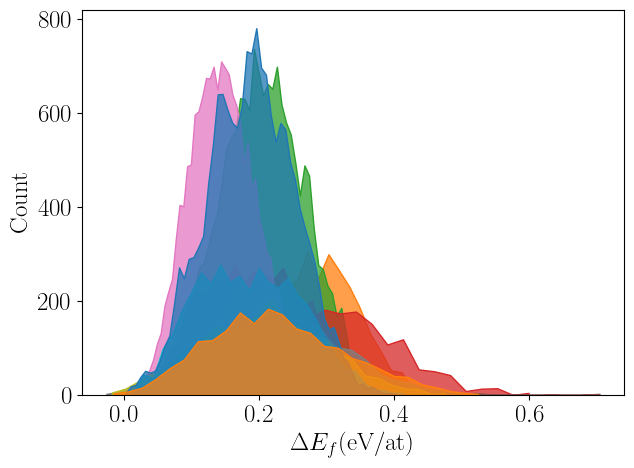

In [88]:
fig, axes = plt.subplots()
for key, serie in Prediction_Values.items():
    sns.histplot(Prediction_Values[key][f'{target_case}__{key[0]}'], element='poly', ax = axes)
axes.set_xlabel(r'$\Delta E_f $(eV/at)')

In [89]:
select_model = '0.7dprojections_0.5os'

In [90]:
coincidence = Prediction_Values[(select_model, 'R')][f'{target_case}__{select_model}'].index.intersection(TRAIN_RBS.index)

In [91]:
difference =TRAIN_RBS.index.difference(coincidence)

In [92]:
TRAIN_RBS.loc[difference]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,1,52,53,0.018868,0.981132,NM,R,0.307309,0.305966,0.304474
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076915,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,52,1,53,0.981132,0.018868,NM,R,0.228834,0.159020,0.081452


In [93]:
len( featurenames)

3

In [94]:
featurenames

{'0.7dprojections_0.5os': '0.7dProjections 0.5OS BOP',
 'ACE': 'ACE',
 'SOAP_specific_small': 'SOAP_specific_small'}

In [95]:
BS_predict.keys()

dict_keys(['R', 'P', 'delta', 'M'])

Text(0.5, 0.01, '$x_{Fe}$')

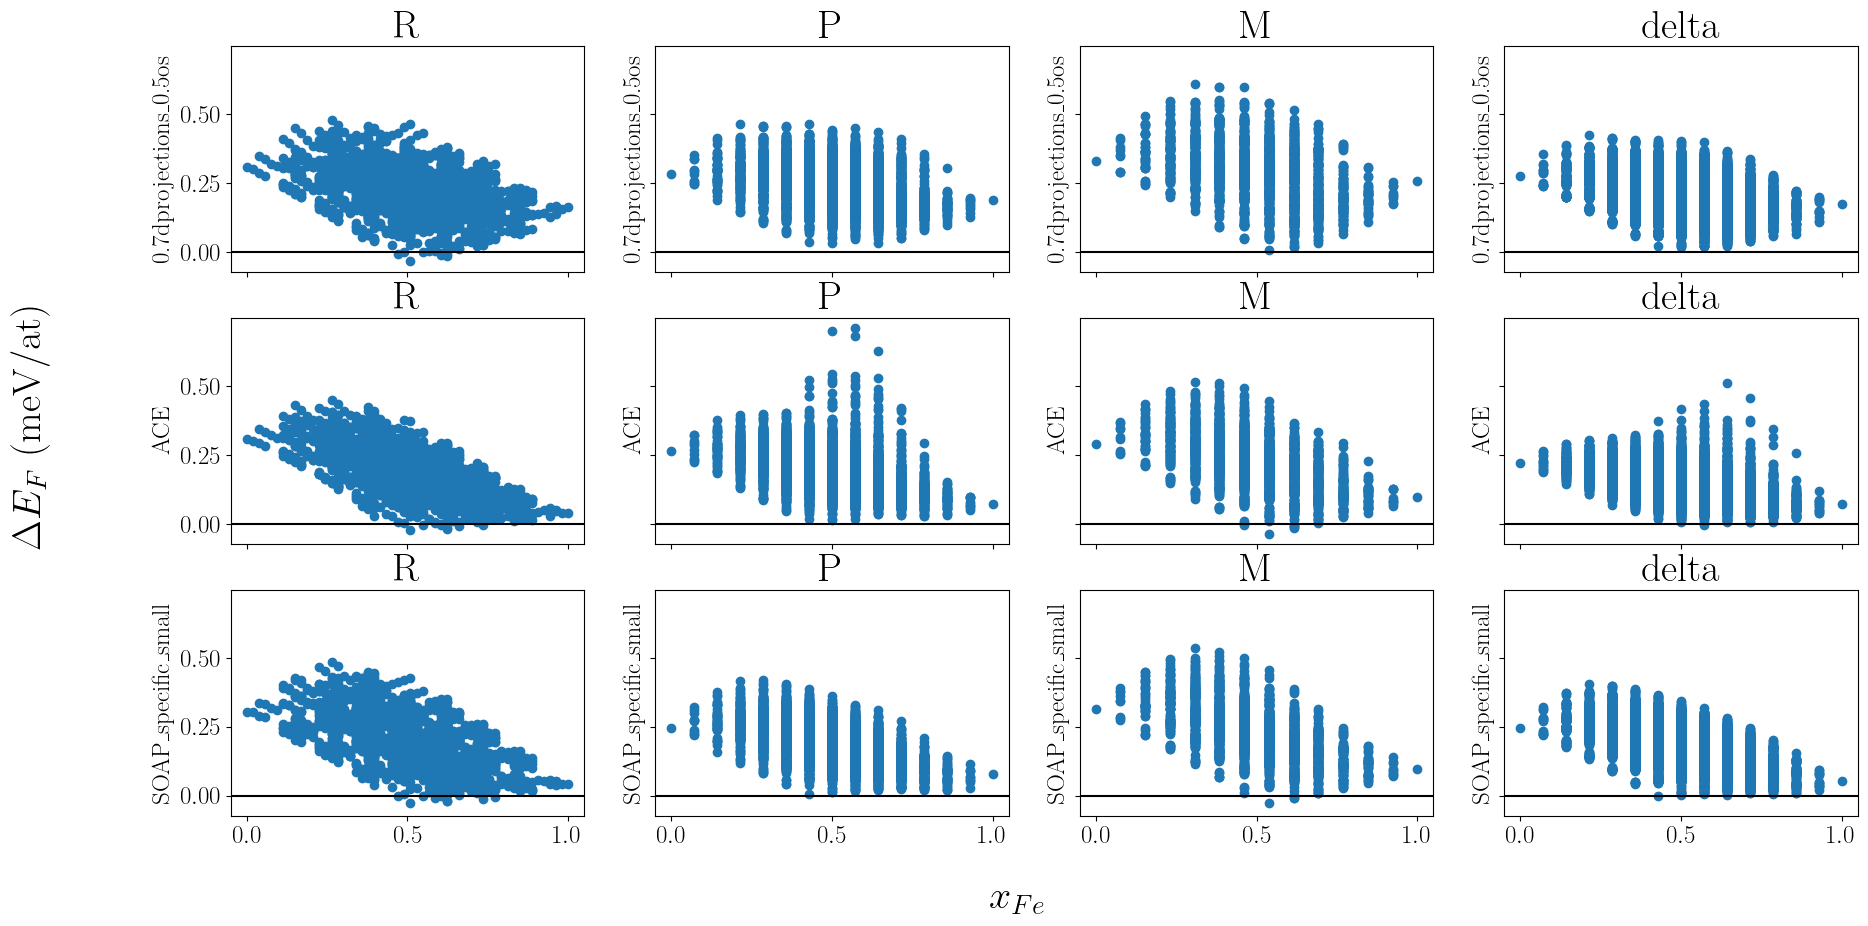

In [96]:
featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
phase_pos = {'R': 0, 'P': 1, 'M': 2, 'delta': 3}
fig, axes = plt.subplots(
    len(featurenames), len(BS_predict),
    figsize = (plt.rcParams['figure.figsize'][0]*3,plt.rcParams['figure.figsize'][1]*2),
    sharey=True, sharex=True)
for (featurename, phase), prediction  in Prediction_Values.items():
    I = featurename_pos[featurename]
    J = phase_pos[phase]
    intersection = BS_predict[phase]['Fe_pv'].index.intersection(prediction[f'{target_case}__{featurename}'].index)
    axes[I, J].scatter(
        BS_predict[phase]['Fe_pv'][intersection],
        prediction[f'{target_case}__{featurename}'][intersection],
    )
    axes[I,J].set_title(phase)
    axes[I,J].set_ylabel(featurename)
    axes[I,J].axhline(c='k')
fig.supylabel(r'$\Delta E_F$ (meV/at)')
fig.supxlabel(r'$x_{Fe}$')

In [98]:
BS_predict['R'].keys()

Index(['num_atoms', 'Fe', 'Mo', 'Fe_pv', 'Mo_sv', 'Mag', 'nelem', 'Structure'], dtype='object')

In [99]:
target_case

'EF_fmbcc'

In [100]:
Prediction_Values.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP_specific_small', 'R'), ('SOAP_specific_small', 'P'), ('SOAP_specific_small', 'delta'), ('SOAP_specific_small', 'M')])

In [101]:
Prediction_Values[('SOAP_specific_small', 'R')]

,EF_fmbcc__SOAP_specific_small,vote_0,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,std_votes
Fe_pv53.R.NM,0.041397,0.036071,0.036350,0.051516,0.037853,0.043439,0.032066,0.045490,0.032744,0.042086,0.056360,0.008000
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.022577,0.028662,0.019982,0.024443,0.018848,0.020075,0.012352,0.030078,0.016387,0.027684,0.027254,0.005911
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,0.039210,0.034768,0.038298,0.044405,0.041397,0.037839,0.030656,0.046576,0.034351,0.035148,0.048668,0.005880
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.023170,0.026578,0.021116,0.024629,0.020466,0.019336,0.011222,0.032514,0.024959,0.024343,0.026535,0.005637
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,0.048146,0.046068,0.050752,0.045192,0.040873,0.045376,0.065882,0.056362,0.052916,0.020489,0.057549,0.012195
...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,0.389782,0.383497,0.376973,0.385975,0.382714,0.395614,0.415621,0.384609,0.392996,0.370632,0.409191,0.013945
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,0.428556,0.425304,0.415958,0.440324,0.436479,0.427355,0.421983,0.429468,0.436798,0.426730,0.425161,0.007445
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,0.336693,0.336239,0.339270,0.349831,0.331860,0.339986,0.335268,0.327856,0.335925,0.335928,0.334770,0.005760
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,0.400667,0.400226,0.393441,0.404530,0.404627,0.400851,0.397697,0.400075,0.406419,0.398042,0.400764,0.003833


In [102]:
from sklearn.metrics import r2_score, mean_squared_error

In [103]:
from scipy.stats import pearsonr, linregress

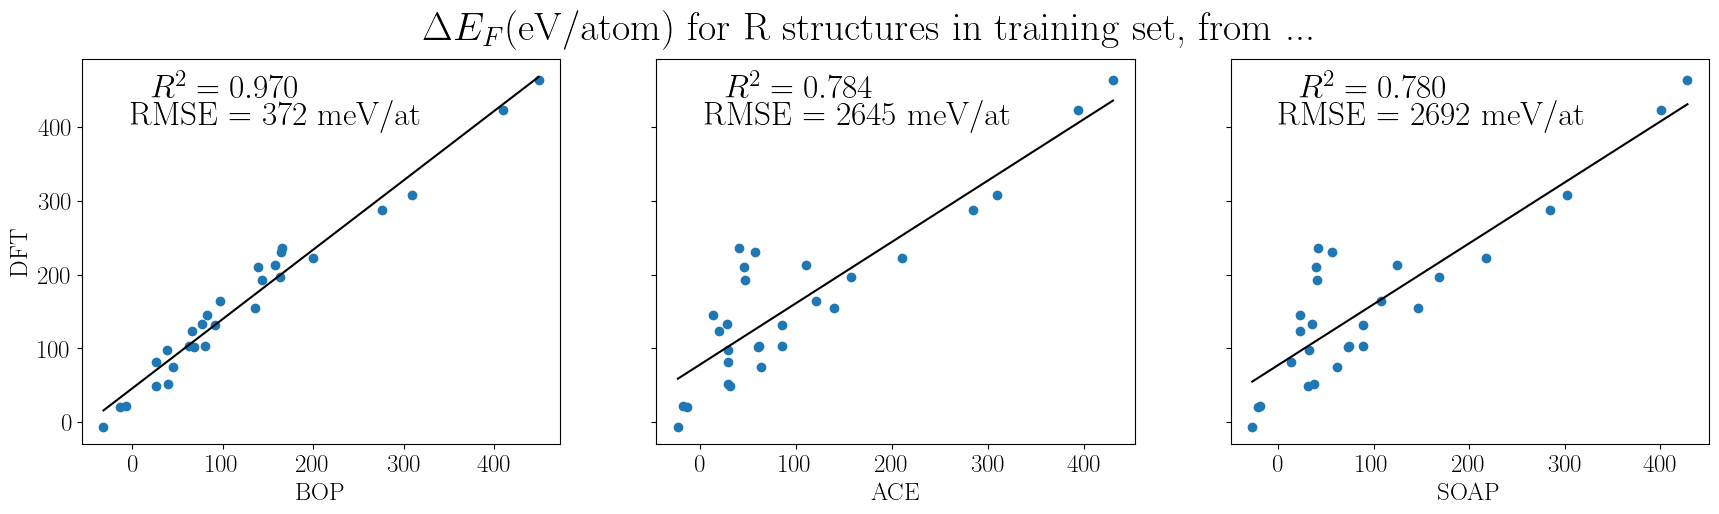

In [104]:
featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
featurename_label ={'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP' }
phase_pos = {'R': 0}#, 'R_old': 1, 'P': 2, 'delta': 3, 'M': 4}
fig, axes = plt.subplots(1, len(featurename_pos), figsize=(plt.rcParams['figure.figsize'][0]*len(featurename_pos), plt.rcParams['figure.figsize'][1]), sharey = True)
for (featuregroup, I), ax in zip(featurename_pos.items(), axes):
    test_split_samples = BS.index.intersection(BS_predict['R'].index)
    targetname = f'{target_case}__{featuregroup}'
    x = Prediction_Values[(featuregroup, 'R')][targetname][test_split_samples]*1000
    y = BS.loc[test_split_samples][target_case]*1000
    reg = np.polyfit(x, y, 1)
    pol = np.poly1d(reg)
    r2 = r2_score(y, pol(x))
    rmse = mean_squared_error(y, pol(x))
    ax.scatter(x, y) 
    ax.plot([x.min(), x.max()], pol([x.min(), x.max()]), 'k')
    ax.annotate (rf'$R^2 = {r2:.3f}$\newline RMSE = {rmse:.0f} meV/at', (0.1, 0.9), xycoords='axes fraction')
    ax.set_xlabel(featurename_label[featuregroup])
axes[0].set_ylabel('DFT')
fig.suptitle(r'$\Delta E_F $(eV/atom) for R structures in training set, from ...')
fig.savefig('Fe-Mo/graphs/Rstructs_Prediction_Vs_DFT.pdf')

In [105]:
BS_predict['P'][BS_predict['P']['Fe_pv'] == 0]

,num_atoms,Fe,Mo,Fe_pv,Mo_sv,Mag,nelem,Structure
Mo_sv56.P-BBBBBBBBBBBB.NM,56,0.0,56.0,0.0,1.0,1,1,11


In [102]:
Prediction_Values.keys()

dict_keys([('0.7dprojections_0.5os', 'R'), ('0.7dprojections_0.5os', 'P'), ('0.7dprojections_0.5os', 'delta'), ('0.7dprojections_0.5os', 'M'), ('ACE', 'R'), ('ACE', 'P'), ('ACE', 'delta'), ('ACE', 'M'), ('SOAP_specific_small', 'R'), ('SOAP_specific_small', 'P'), ('SOAP_specific_small', 'delta'), ('SOAP_specific_small', 'M')])

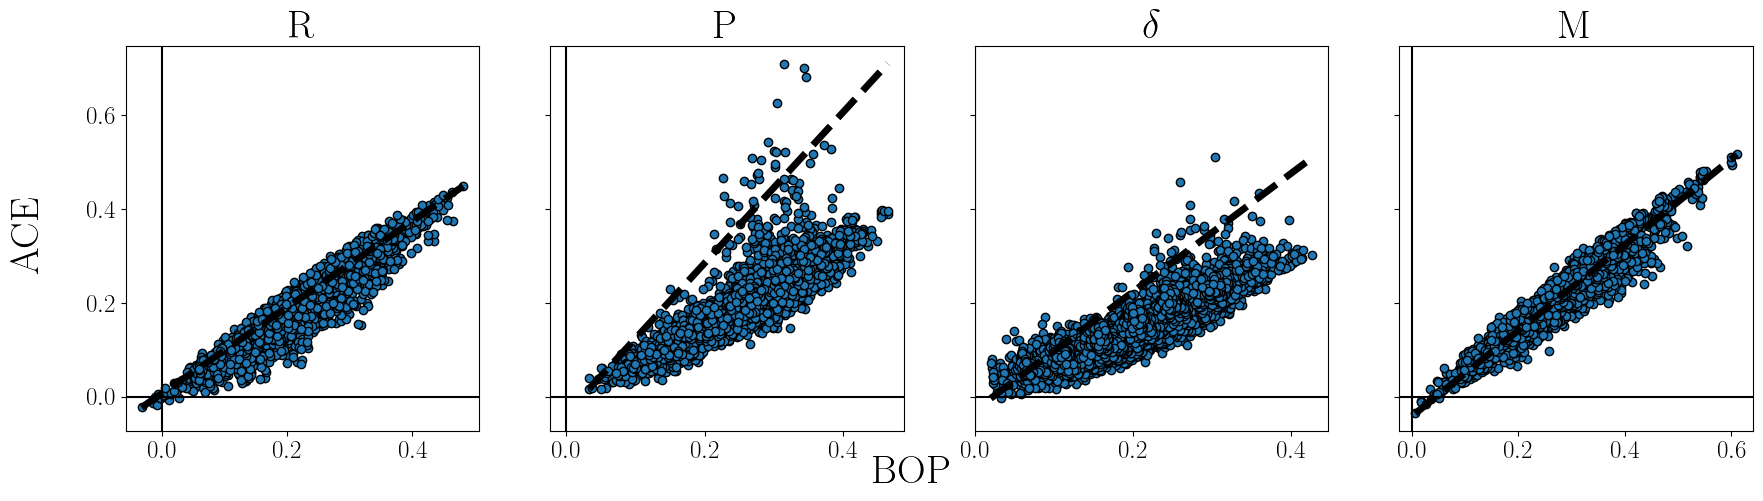

In [103]:
#featurename_pos ={'0.7dprojections_0.5os': 0, 'ACE': 1}
phase_pos = {'R': 0, 'P': 2, 'delta': 3, 'M': 4}#, 'R_old': 1}
phase_label = {'R': 'R', 'P': 'P', 'delta': r'$\delta$', 'M': 'M'}
bopmodel = '0.7dprojections_0.5os'
acemodel = 'ACE'
fig, axes = plt.subplots(
    1, len(phase_pos),
    figsize = (plt.rcParams['figure.figsize'][0]*3,plt.rcParams['figure.figsize'][1]),
    sharey=True)
for phase, axes  in zip(phase_pos, axes):
    if phase == 'R_old':
        continue
    intersection = Prediction_Values[(bopmodel, phase)].index.intersection(Prediction_Values[(acemodel, phase)].index)
    x = Prediction_Values[(bopmodel, phase)][target_case+'__'+bopmodel][intersection]
    y = Prediction_Values[(acemodel, phase)][target_case+'__'+acemodel].loc[intersection]
    axes.scatter(x,y,edgecolor='k')
    axes.plot([x.min(), x.max()], [y.min(), y.max()], '--k', lw=5)
    axes.set_title(phase_label[phase])
    axes.axhline(c='k')
    axes.axvline(c='k')

fig.supxlabel('BOP', y=-0.01)
fig.supylabel(acemodel, x=0.07)
fig.savefig('Fe-Mo/graphs/Fe-Mo-PredictionDifferences.pdf')

# Predicted convex hulls 

In [104]:
from Tools.DatasetTools.Tools import Plotting, PlottingChulls

In [105]:
from scipy.spatial import ConvexHull

In [106]:
from matplotlib.lines import Line2D

In [107]:
for (model, phase), prediction_values in Prediction_Values.items() :
    if (target_case, model) not in BS_predict[phase].columns:
        BS_predict[phase] = pd.concat([BS_predict[phase], prediction_values], axis = 1)

In [108]:
BS_predict.keys()#['R'].filter(regex=target_case)

dict_keys(['R', 'P', 'delta', 'M'])

In [109]:
phasesloc= {'R':0, 'M': 1,'P':2 ,'delta':3}
targetsloc = {target_name: i for i, target_name in enumerate(BS_predict['R'].filter(regex='EF_nmhcp').columns)}

In [110]:
feature_labels = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE', 'SOAP_specific_small': 'SOAP'}

In [111]:
phase_labels = {'delta': r'$\delta$', 'R': '$R$', 'M': '$M$', 'P': '$P$'}

In [112]:
experimental_range = {
    'sigma': [0.4,0.55],
    'R' : [0.6,0.65],
    'mu' : [0.6, 0.55],
    'lambda': [0.655, 0.66]
}

In [113]:
x = experimental_range['R']

In [114]:
BS_predict[phase].filter(regex='EF_')#columns#['Fe_pv', target_name, 'nelem']

,EF_fmbcc__0.7dprojections_0.5os,EF_fmbcc__ACE,EF_fmbcc__SOAP_specific_small
Fe_pv52.M-AAAAAAAAAAA.NM,0.257960,0.098146,0.097894
Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM,0.198292,0.065718,0.071351
Fe_pv48Mo_sv4.M-AAAAAAAAABA.NM,0.177115,0.074158,0.086009
Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM,0.109985,0.038360,0.052236
Fe_pv48Mo_sv4.M-AAAAAAAABAA.NM,0.176460,0.084885,0.097104
...,...,...,...
Fe_pv4Mo_sv48.M-BBBBBBBBABB.NM,0.371135,0.343600,0.377497
Fe_pv8Mo_sv44.M-BBBBBBBBBAA.NM,0.493669,0.436552,0.448249
Fe_pv4Mo_sv48.M-BBBBBBBBBAB.NM,0.413439,0.370494,0.391163
Fe_pv4Mo_sv48.M-BBBBBBBBBBA.NM,0.408348,0.367071,0.379082


In [115]:
P = Plotting()
inchull = {}
opo_chull = {}
CHULLS = {}

for target_name, J in targetsloc.items():
    CHULLS[target_name] = {}
    for phase, I in phasesloc.items():
        plottable = BS_predict[phase][['Fe_pv', target_name, 'nelem']].dropna(axis=0).sort_values(by=['Fe_pv', target_name])
        chull = P.get_convex_hulls(
            {phase: plottable}, ['Fe_pv'], getproperty=target_name, viewpoint=(0.0, -10)
        )
        CHULLS[target_name].update(chull)

        all_vertices_low = np.unique(np.hstack(chull[phase].simplices[chull[phase].good]))
        inchull[(phase, target_name)] = plottable.iloc[all_vertices_low].sort_values(by='Fe_pv')

print(f'Generated convex hulls for {len(targetsloc)} targets and {len(phasesloc)} phases.')

Generated convex hulls for 0 targets and 4 phases.


In [116]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

## save chulls to csv

In [117]:
for (phase, pred__model), chulldata in inchull.items():
    phase_chull_location = os.path.join(ValidationDataLocation, 'inchull', phase)
    os.makedirs(phase_chull_location, exist_ok=True)
    chull_data_loc = os.path.join(phase_chull_location, f'{ pred__model }.csv')
    chulldata.to_csv(chull_data_loc)

## save uncertainties to csv

In [118]:
for (pred__model, phase), predictionvotes in Prediction_Values.items():
    phase_chull_location = os.path.join(ValidationDataLocation, 'inchull', phase)
    os.makedirs(phase_chull_location, exist_ok=True)
    votes_data_loc = os.path.join(phase_chull_location, f'{ pred__model }:votes.csv')
    predictionvotes.to_csv(votes_data_loc)

# Recover samples in convex hull for validation 

In [119]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

In [120]:
if not os.path.exists(ValidationDataLocation):
    os.makedirs(ValidationDataLocation)
for (phase, target_name), inchullist in inchull.items():
    group_loc = os.path.join(ValidationDataLocation, 'inchull', phase)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    #inchullist.to_csv(os.path.join(group_loc, 'list.csv'))
    for index, atoms in AtomsObjects[phase]['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, direct=True, format='vasp')
        validation_structure_location = validation_atoms_location.replace('vasp', 'cfg')
        atoms.write(validation_structure_location, format='cfg')

In [121]:
inchull[('M', 'EF_nmhcp__ACE')]

KeyError: ('M', 'EF_nmhcp__ACE')

## Plot predicted CHULL

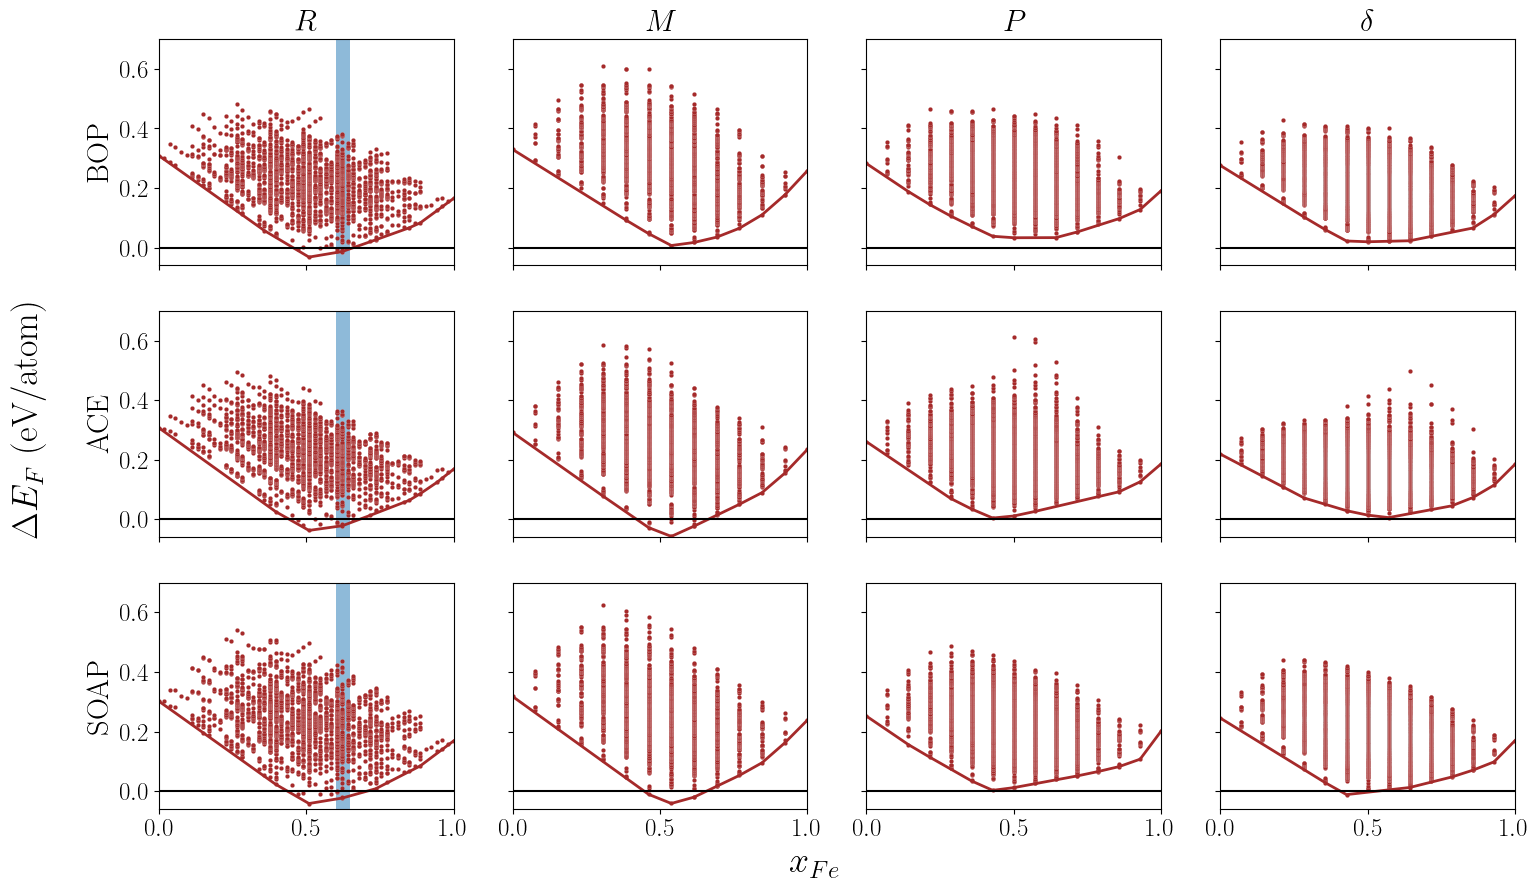

In [ ]:
figsize = plt.rcParams['figure.figsize']
fig, axes = plt.subplots(
    len(targetsloc), len(phasesloc),
    sharey=True, sharex=True,
    figsize=(figsize[0] * 2.5, figsize[1] * 2),
)

for target_name, J in targetsloc.items():
    featurename = target_name.replace(target_case + '__', '')
    axes[J, 0].set_ylabel(feature_labels[featurename], fontsize=22)

    for phase, I in phasesloc.items():
        plottable = BS_predict[phase][['Fe_pv', target_name, 'nelem']].dropna(axis=0).sort_values(by=['Fe_pv', target_name])

        if phase == 'R':
            axes[J, I].fill_between(experimental_range[phase], -0.1, 0.7, alpha=0.5)

        axes[J, I].scatter(
            plottable['Fe_pv'].values, plottable[target_name].values,
            c='brown', s=10, lw=0.1, edgecolor='w'
        )
        axes[0, I].set_title(phase_labels[phase], fontsize=22)

        l = axes[J, I].plot(
            inchull[(phase, target_name)]['Fe_pv'].values,
            inchull[(phase, target_name)][target_name].values,
            '-', color='brown', label='chull', linewidth=2
        )

        axes[J, I].axhline(c='k')
        axes[J, I].set_ylim([-0.06, 0.7])
        axes[J, I].set_xlim([0, 1])

fig.subplots_adjust(wspace=0.2, hspace=0.2)
fig.supylabel(r'$\Delta E_F$ (eV/atom)', x=0.04, fontsize=26)
fig.supxlabel('$x_{Fe}$', fontsize=26, y=0.04)
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_compare_predictions.pdf')
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_compare_predictions.png', dpi=300)

## R chull with uncertainties

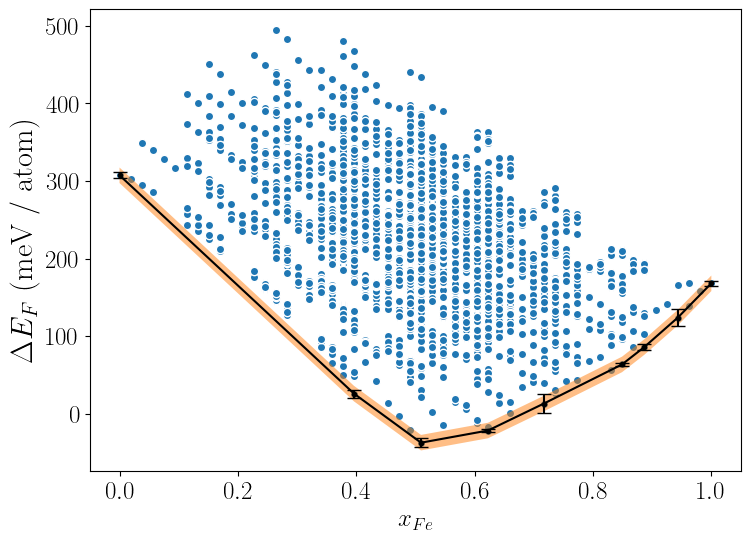

In [ ]:
featurename_pos = {'ACE':1}#{'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
featurename_label = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE',  'SOAP_specific_small': 'SOAP'}
test_errors = {'0.7dprojections_0.5os': 0.018, 'ACE':0.010, 'SOAP_specific_small': 0.015}#?
phase_pos = {'R': 0,} # 'M': 1, 'P': 2, 'delta': 3}#, 'M': 4}
ncols = int(len(phase_pos))
nrows = int(len(featurename_pos))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(plt.rcParams['figure.figsize'][0]*ncols*1.2,plt.rcParams['figure.figsize'][1]*nrows*1.2),
    sharey=True,
    sharex=True
    )
for featuregroup, I in featurename_pos.items():
    targetname = f'{target_case}__{featuregroup}'
    for phase, J in phase_pos.items():
        training_samples = BS.index.str.contains(f'\\.{phase}-')
        index1 = BS_predict[phase].index
        index2 = Prediction_Values[(featuregroup, phase)].index
        intersection = index1.intersection(index2)
        targetname = f'{target_case}__{featuregroup}'
        this_chull = inchull[(phase, targetname)].index
        axes.scatter(BS_predict[phase]['Fe_pv'][intersection], Prediction_Values[(featuregroup, phase)][targetname][intersection]*1000, label = 'Predictions', edgecolor='w')
        axes.plot(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            'k',
            label = 'convex hull'
            )
        axes.fill_between(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 - test_errors[featuregroup]*1000, 
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 + test_errors[featuregroup]*1000, 
            label = 'test error',
            alpha=0.5
            )
        axes.errorbar(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            yerr= Prediction_Values[(featuregroup, phase)]['std_votes'][this_chull].values*1000,
            fmt='.k',
            capsize=5,
#            lolims=True,
            label = 'std from bag of predictions'
            )
        if len(training_samples) <0:
            continue
#        axes.set_title(phase_label[phase], fontsize=22)
#    axes.set_ylabel(featurename_label[featuregroup], fontsize=22)
axes.set_xlabel('$x_{Fe}$')#, fontsize=24)
axes.set_ylabel(rf'$\Delta E_F$ (meV / atom)', fontsize=22)
fig.savefig(f'{dataset}/graphs/{dataset}_R_{targetname}_convexhull.pdf')

## Predicted CHULLs with uncertainties

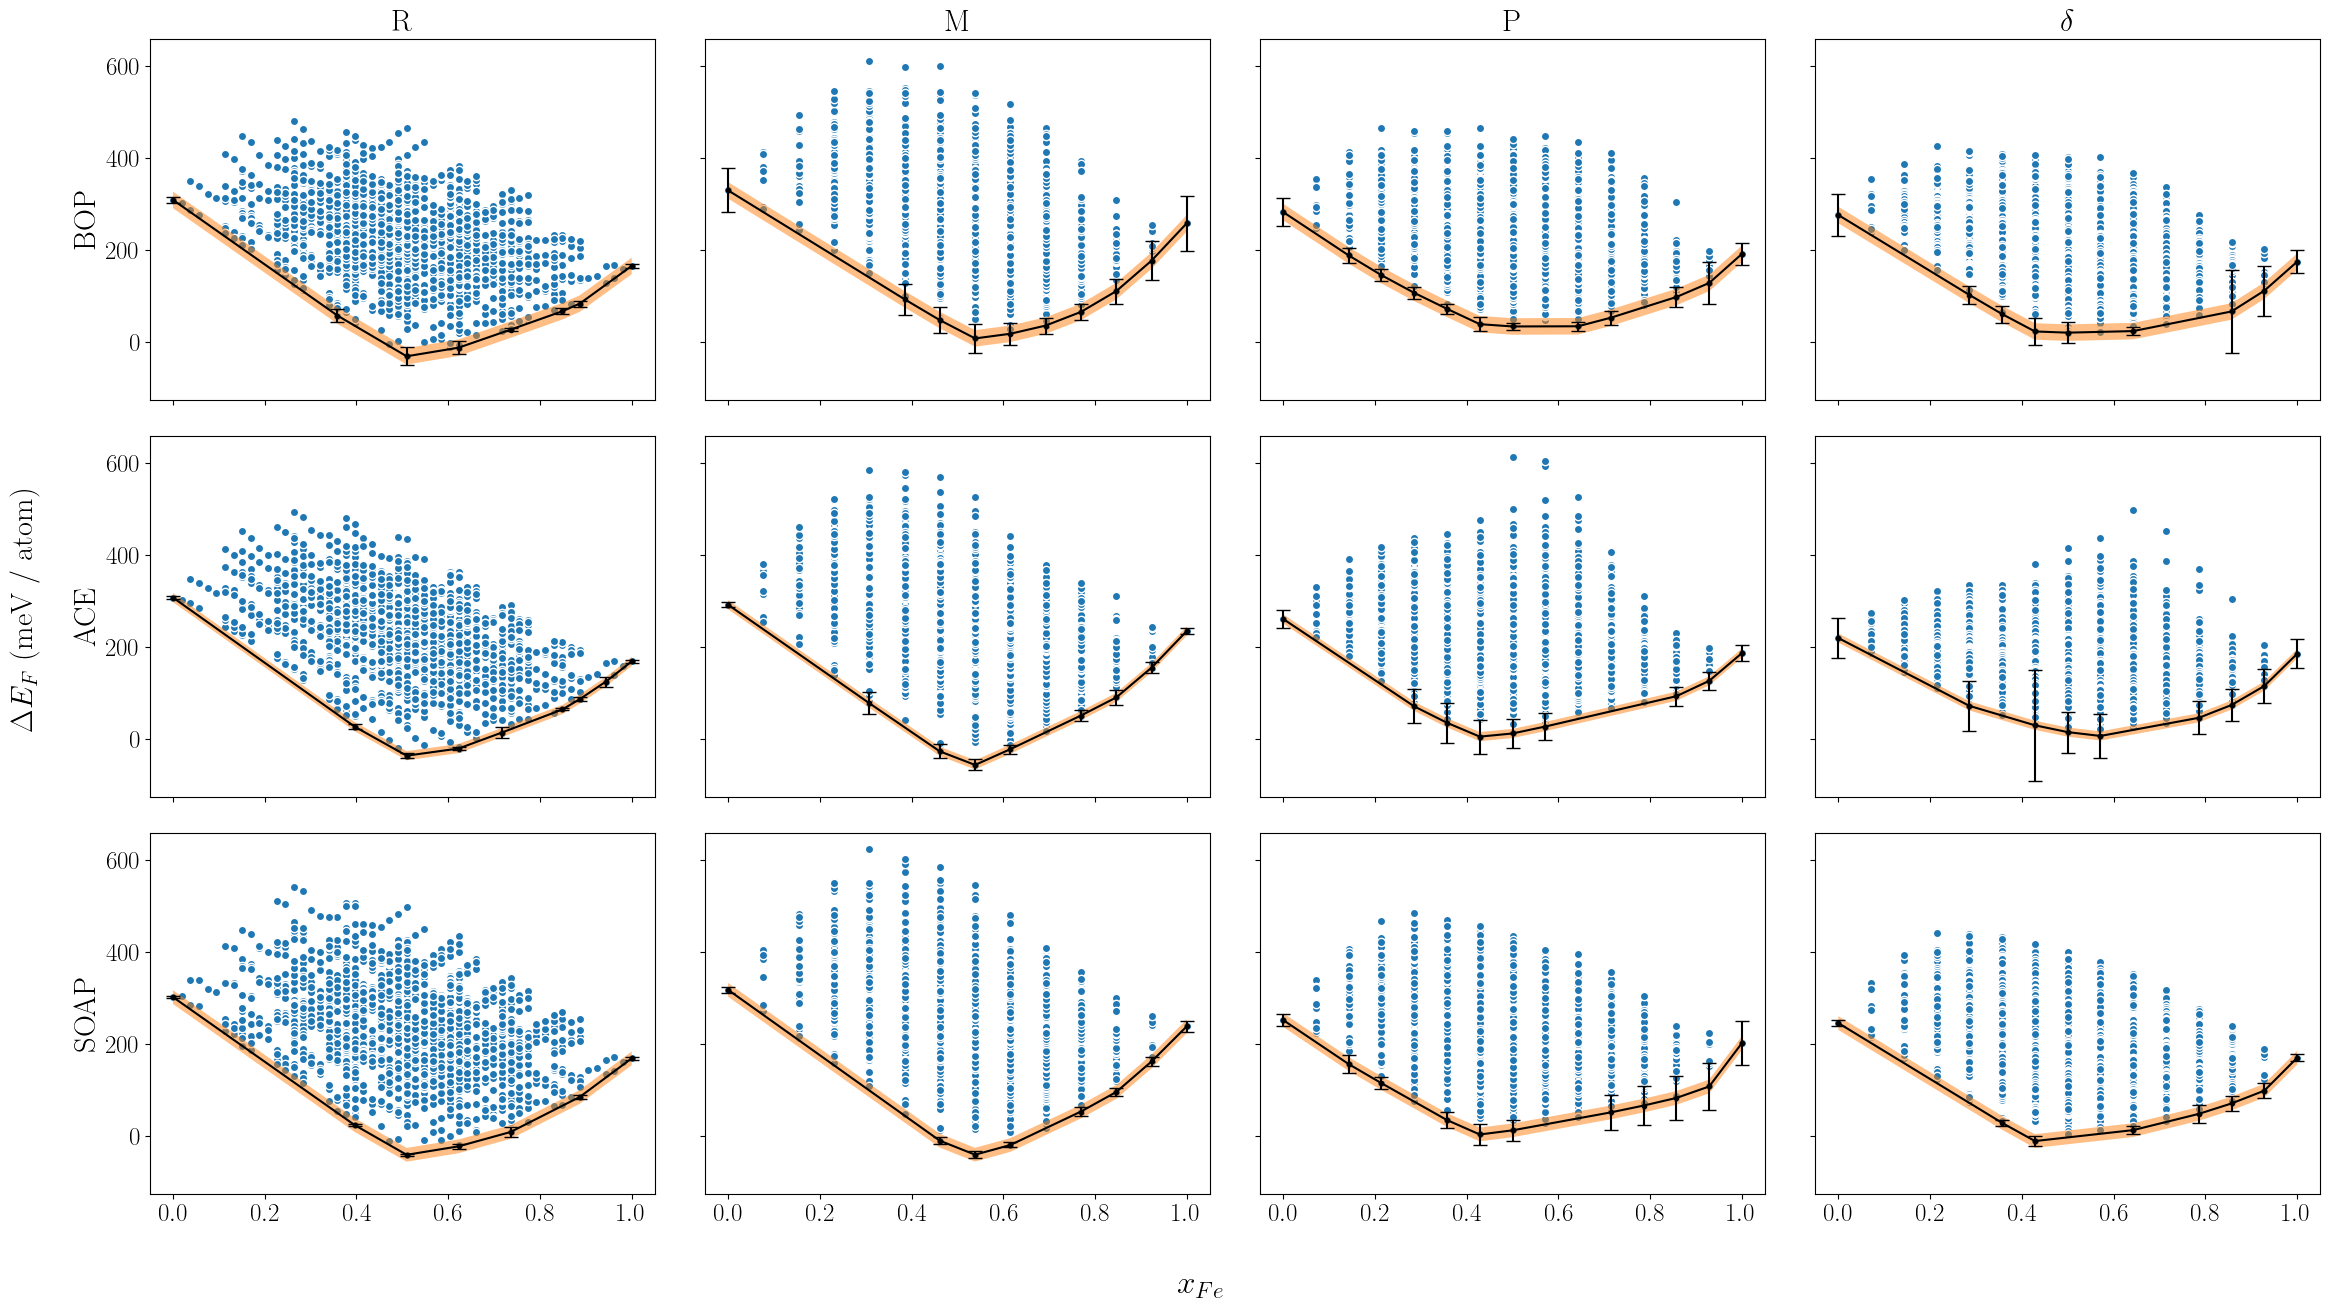

In [ ]:
featurename_pos = {'0.7dprojections_0.5os': 0, 'ACE': 1, 'SOAP_specific_small': 2}
featurename_label = {'0.7dprojections_0.5os': 'BOP', 'ACE': 'ACE',  'SOAP_specific_small': 'SOAP'}
test_errors = {'0.7dprojections_0.5os': 0.018, 'ACE':0.010, 'SOAP_specific_small': 0.015}#?
phase_pos = {'R': 0, 'M': 1, 'P': 2, 'delta': 3}#, 'M': 4}
#fig, axes = plt.subplots(1, len(featurename_pos), figsize=(plt.rcParams['figure.figsize'][0]*2, plt.rcParams['figure.figsize'][1]), sharey = True)
ncols = int(len(phase_pos))
nrows = int(len(featurename_pos))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(plt.rcParams['figure.figsize'][0]*ncols,plt.rcParams['figure.figsize'][1]*nrows),
    sharey=True,
    sharex=True
    )
for featuregroup, I in featurename_pos.items():
    targetname = f'{target_case}__{featuregroup}'
    for phase, J in phase_pos.items():
        training_samples = BS.index.str.contains(f'\\.{phase}-')
        index1 = BS_predict[phase].index
        index2 = Prediction_Values[(featuregroup, phase)].index
        intersection = index1.intersection(index2)
        targetname = f'{target_case}__{featuregroup}'
        this_chull = inchull[(phase, targetname)].index
        axes[I,J].scatter(BS_predict[phase]['Fe_pv'][intersection], Prediction_Values[(featuregroup, phase)][targetname][intersection]*1000, label = 'Predictions', edgecolor='w')
        axes[I,J].plot(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            'k',
            label = 'convex hull'
            )
        axes[I,J].fill_between(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 - test_errors[featuregroup]*1000, 
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000 + test_errors[featuregroup]*1000, 
            label = 'test error',
            alpha=0.5
            )
        axes[I,J].errorbar(
            BS_predict[phase]['Fe_pv'][this_chull].values,
            Prediction_Values[(featuregroup, phase)][targetname][this_chull].values*1000, 
            yerr= Prediction_Values[(featuregroup, phase)]['std_votes'][this_chull].values*1000,
            fmt='.k',
            capsize=5,
#            lolims=True,
            label = 'std from bag of predictions'
            )
        if len(training_samples) <0:
            continue
#        axes[I,J].scatter(
#            BS['Fe_pv'][training_samples],
#            BS[target_case][training_samples]*1000,
#            edgecolor='k',
#            label='DFT calculations',
#            s = 100
#            )
        axes[0, J].set_title(phase_label[phase], fontsize=22)
#    axes[0,I].legend( fontsize=plt.rcParams['font.size']*0.6,bbox_to_anchor = (1, 1),)
    axes[I,0].set_ylabel(featurename_label[featuregroup], fontsize=22)
fig.supxlabel('$x_{Fe}$', fontsize=24, y=0.04)
fig.subplots_adjust(hspace=0.1, wspace=0.1)
fig.supylabel(r'$\Delta E_F$ (meV / atom)', fontsize=22, x=0.075)
fig.savefig(f'{dataset}/graphs/{dataset}_R_{targetname}_convexhull.pdf')
#fig.supxlabel('$x_{Fe}$', y=-0.01)
#fig.supylabel (r'$\Delta E_F$ (meV / atom)')
#fig.legend([Line2D([0],[0], ))])

In [ ]:
BOP_vs_ACE = (Prediction_Values[(bopmodel, 'R')][f'{target_case}__{bopmodel}'] - Prediction_Values[(acemodel, 'R')][f'{target_case}__{acemodel}']).abs()

## difference as function to distance to the hull

In [ ]:
from scipy.spatial import Delaunay

In [ ]:
xp = inchull[('R',f'{target_case}__{acemodel}')]['Fe_pv']
yp = inchull[('R',f'{target_case}__{acemodel}')][f'{target_case}__{acemodel}']

In [ ]:
import pdb

In [ ]:
def distance_to_chull(x, y,  chull_def: pd.core.series.Series, valuename : str):
    y_in_chull = np.interp(x, xp, yp,)
    return y - y_in_chull

In [ ]:
targetname=f'{target_case}__ACE'
distance_to_chull(BS_predict['R']['Fe_pv']['Fe_pv53.R.NM'], Prediction_Values[(acemodel, 'R')][targetname]['Fe_pv53.R.NM'], inchull[('R',f'{target_case}__{acemodel}')], f'{target_case}__{acemodel}' )

0.0

In [ ]:
xy = pd.concat([BS_predict['R']['Fe_pv'], Prediction_Values[(acemodel, 'R')][targetname]], axis = 1)

In [ ]:
distances_to_chull = pd.Series([], name = 'DistanceToChull')
for index, compound in xy.iterrows():
    distances_to_chull[index] = distance_to_chull(compound['Fe_pv'], compound[targetname], inchull[('R', f'{target_case}__{acemodel}')], targetname)

In [ ]:
selection = xy.index.str.contains('NM')

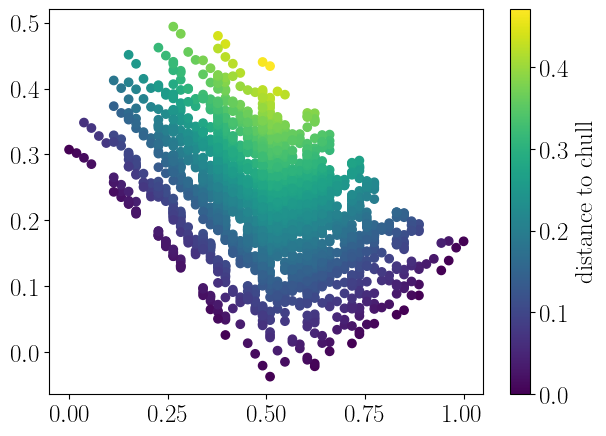

In [ ]:
plt.scatter(xy['Fe_pv'][selection], xy[targetname][selection], c=distances_to_chull[selection])
plt.colorbar(label='distance to chull')

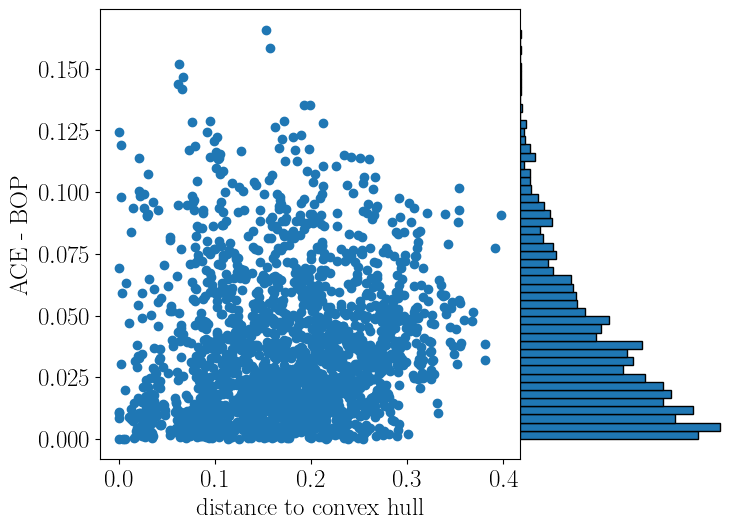

In [ ]:
fig = plt.figure()
axes = fig.add_axes([0.1, 0.1, 0.6, 0.9])
ax2 = fig.add_axes([0.7, 0.1, 0.3,0.9], sharey = axes)
ax2.set_axis_off()
axes.scatter(distances_to_chull[selection], BOP_vs_ACE[selection])
hist = ax2.hist(BOP_vs_ACE[selection], orientation='horizontal', bins = 50,edgecolor='k')
axes.set_xlabel ('distance to convex hull')
axes.set_ylabel('ACE - BOP')
fig.savefig(f'{dataset}/graphs/{dataset}_error_vs_distance_to_chull.pdf')

Text(0.5, 1.0, 'Kernel Ridge / EF_nmhcp__ACE')

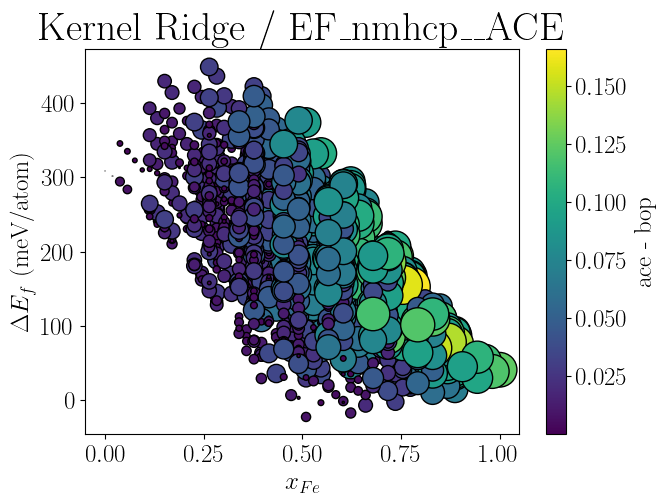

In [ ]:
fig, axes = plt.subplots()
mapble = axes.scatter(xy['Fe_pv'], xy[targetname]*1000, c=BOP_vs_ACE, s=BOP_vs_ACE*5000, edgecolor='k')#c=distances_to_chull)
plt.colorbar(label='ace - bop', mappable=mapble)
axes.set_xlabel(r'$x_{Fe}$')
axes.set_ylabel(r'$\Delta E_f$ (meV/atom)')
axes.set_title(ModelName+' / '+targetname)

In [ ]:
Phases = {'R':'R', 'delta': r'$\delta$', 'P': 'P', 'M':'M'}

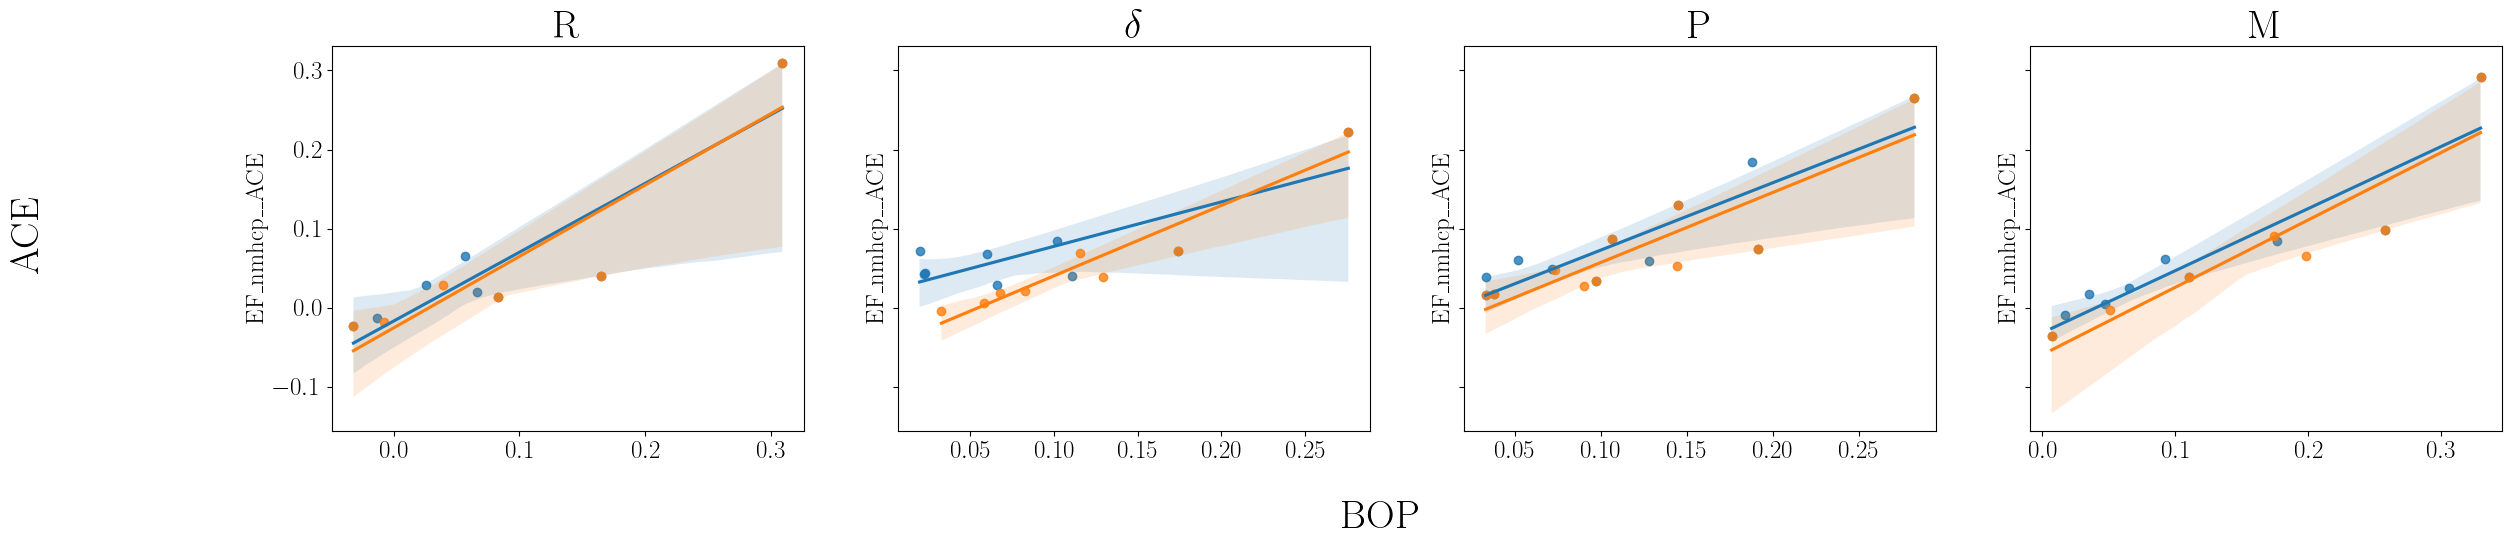

In [ ]:
fig, axes = plt.subplots(1, len(Phases), sharey=True, figsize=(plt.rcParams['figure.figsize'][0]*len(Phases), plt.rcParams['figure.figsize'][1]))
for (phase, title), axes  in zip(Phases.items(), axes):
    inchull_bop = inchull[(phase, 'EF_nmhcp__0.7dprojections_0.5os')].index
    inchull_ace = inchull[(phase, 'EF_nmhcp__ACE')].index
    sbop, pbop = pearsonr(Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_bop], Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_bop])
    sace, pace = pearsonr(Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_ace], Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_ace])
    sns.regplot(
        x=Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_bop]
        , y=Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_bop], label = f'BOP, $R^2 = {sbop:.3f}$',
        ax=axes
    )
    sns.regplot(
        x=Prediction_Values[('0.7dprojections_0.5os', phase)]['EF_nmhcp__0.7dprojections_0.5os'][inchull_ace], 
        y=Prediction_Values[('ACE', phase)]['EF_nmhcp__ACE'][inchull_ace], label = f'ACE, $R^2 = {sace:.3f}$', ax = axes, 
    )
    axes.set_xlabel('')
    axes.set_title(title)
fig.supxlabel ('BOP', y=-0.1)
fig.supylabel ('ACE', x=0.01)
plt.savefig(f'{dataset}/graphs/samples_in_convex_hull.pdf')

# Recover samples in convex hull for validation 

In [ ]:
ValidationDataLocation = os.path.join(dataset, 'data', 'Validation')

In [ ]:
ValidationDataLocation

'Fe-Mo/data/Validation'

In [ ]:
pd.concat(inchull, axis =0).to_csv(os.path.join(ValidationDataLocation, 'inchull.csv'))

In [ ]:
if not os.path.exists(ValidationDataLocation):
    os.makedirs(ValidationDataLocation)
for (phase, target_name), inchullist in inchull.items():
    group_loc = os.path.join(ValidationDataLocation, 'inchull', phase)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    #inchullist.to_csv(os.path.join(group_loc, 'list.csv'))
    for index, atoms in AtomsObjects[phase]['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, direct=True, format='vasp')
        validation_structure_location = validation_atoms_location.replace('vasp', 'cfg')
        atoms.write(validation_structure_location, format='cfg')

In [ ]:
inchull.keys()

dict_keys([('R', 'EF_nmhcp__0.7dprojections_0.5os'), ('M', 'EF_nmhcp__0.7dprojections_0.5os'), ('P', 'EF_nmhcp__0.7dprojections_0.5os'), ('delta', 'EF_nmhcp__0.7dprojections_0.5os'), ('R', 'EF_nmhcp__ACE'), ('M', 'EF_nmhcp__ACE'), ('P', 'EF_nmhcp__ACE'), ('delta', 'EF_nmhcp__ACE'), ('R', 'EF_nmhcp__SOAP_specific_small'), ('M', 'EF_nmhcp__SOAP_specific_small'), ('P', 'EF_nmhcp__SOAP_specific_small'), ('delta', 'EF_nmhcp__SOAP_specific_small')])

In [ ]:
inchull[('delta', 'EF_nmhcp__ACE')]


,Fe_pv,EF_nmhcp__ACE,nelem
Mo_sv56.delta-BBBBBBBBBBBBBB.NM,0.000000,0.221917,1
Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM,0.285714,0.069056,2
Fe_pv24Mo_sv32.delta-BBBBBABBABAAAA.NM,0.428571,0.019085,2
Fe_pv32Mo_sv24.delta-BBBAABBBAAAAAA.NM,0.571429,-0.003902,2
Fe_pv44Mo_sv12.delta-BBBAAAAAAAAAAA.NM,0.785714,0.005425,2
Fe_pv48Mo_sv8.delta-BABAAAAAAAAAAA.NM,0.857143,0.021017,2
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,0.928571,0.039309,2
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,1.000000,0.071865,1


In [ ]:
inchullist

,Fe_pv,EF_nmhcp__SOAP_specific_small,nelem
Mo_sv56.delta-BBBBBBBBBBBBBB.NM,0.000000,0.245693,1
Fe_pv24Mo_sv32.delta-BBBBBBBBAAAAAA.NM,0.428571,-0.000153,2
Fe_pv36Mo_sv20.delta-BBBAABBAAAAAAA.NM,0.642857,0.002951,2
Fe_pv44Mo_sv12.delta-AABBBAAAAAAAAA.NM,0.785714,0.008075,2
Fe_pv48Mo_sv8.delta-AABBAAAAAAAAAA.NM,0.857143,0.011542,2
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,0.928571,0.021567,2
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,1.000000,0.055023,1


In [ ]:
target_name

'EF_nmhcp__SOAP_specific_small'

In [ ]:
for (phase, target_name), inchullist in opo_chull.items():
    group_loc = os.path.join(ValidationDataLocation, 'opochull', phase, target_name)
    if not os.path.exists(group_loc):
        os.makedirs(group_loc)
    inchullist.to_csv(os.path.join(group_loc, 'list.csv'))
    for index, atoms in AtomsObjects[phase]['atoms'][inchullist.index].items():
        validation_atoms_location = os.path.join(group_loc, f'{index}.vasp')
        atoms.write(validation_atoms_location, format='vasp',sort=True)


In [ ]:
inchull[('R','EF_nmhcp__0.7dprojections_0.5os' )].shape

(8, 3)

In [ ]:
AtomsObjects[phase]['atoms'][inchullist.index]

Mo_sv56.delta-BBBBBBBBBBBBBB.NM           (Atom('Mo', [1.7119784720347544, 4.69216107593...
Fe_pv24Mo_sv32.delta-BBBBBBBBAAAAAA.NM    (Atom('Mo', [1.645442447939846, 4.509800288397...
Fe_pv36Mo_sv20.delta-BBBAABBAAAAAAA.NM    (Atom('Mo', [1.6100554815164523, 4.41281230101...
Fe_pv44Mo_sv12.delta-AABBBAAAAAAAAA.NM    (Atom('Fe', [1.5855714240489056, 4.34570681849...
Fe_pv48Mo_sv8.delta-AABBAAAAAAAAAA.NM     (Atom('Fe', [1.5730406130392627, 4.31136258775...
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM     (Atom('Fe', [1.5603069161817937, 4.27646229097...
Fe_pv56.delta-AAAAAAAAAAAAAA.NM           (Atom('Fe', [1.5473619161942118, 4.24098285822...
Name: atoms, dtype: object